# Intro to Programming III: For loops, numpy arrays, and image analysis

Today, we will be introducing the data type: **numpy arrays**. Numpy arrays are used to store and compute matrices (=tables with numbers). Numpy arrays have many applications, one of which is digital images.

In this lecture, we will:

* Learn the digital images are matrices
* Introduce for loops and indexing in numpy arrays
* Interact with various images in Python
  * gray scale images
  * color images
  * 3d images
* Image analysis - counting the number of cells in a microscope image


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt # for plotting and displaying images
import skimage # for image analysis operations
import requests, zipfile # for downloading example image files

# Part 0: For Loops and Arrays

A **numpy array** is a grid of numbers — like a Python list, but designed for math. Unlike lists, all elements must be the same type (e.g., all integers or all floats), and numpy gives us fast operations like addition, slicing, and statistics that work on the entire array at once.

We create a numpy array by calling `np.array()` and passing a list of values.

In [2]:
myarray = np.array([1,2,3,4,5,6])

In [3]:
# check the size of the array
myarray.size

6

## For loops

A **for loop** repeats a block of code once for each item in a sequence. The two most common patterns are:

1. `for element in array:` — iterate over values directly
2. `for i in range(n):` — iterate over indices (useful when you need to know *where* you are)

Both do the same thing here, but the index-based approach (2) becomes important when you need to access multiple arrays at the same position, or when you want to use `i` inside the loop.

In [4]:
# print each element of an array
for element in myarray:
  print(element)

1
2
3
4
5
6


In [5]:
for i in range(myarray.size):
  print(myarray[i])

1
2
3
4
5
6


## 2D arrays (matrices)

Arrays can have more than one dimension. A **2D array** is like a table with rows and columns. We create one by passing a list of lists to `np.array()`.

The shape of a 2D array is described as `(rows, columns)`. This will become very important when we work with images — a grayscale image is just a 2D array where each value is a pixel brightness.

In [6]:
# arrays can be 1, 2, 3, ... n dimensional
my2darray = np.array([[1,2,3,4], [5,6,7,8]])
my2darray

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [7]:
# how do we iteratively print each element of a 2-d array?
for element in my2darray:
  print(element)

[1 2 3 4]
[5 6 7 8]


### Indexing for numpy arrays

## Indexing

Indexing lets us extract elements or regions from an array.

Key syntax:
- `array[i]` — single element at position `i` (0-based)
- `array[start:stop]` — slice from `start` up to (but not including) `stop`
- `array[::step]` — every `step`-th element
- `array[-1]` — last element; negative indices count from the end

For 2D arrays: `array[row, col]` — comma separates dimensions.

In [8]:
myarray

array([1, 2, 3, 4, 5, 6])

In [9]:
# 3rd element onwards
myarray[3:]

array([4, 5, 6])

In [10]:
# up to 3rd element
myarray[:3]

array([1, 2, 3])

In [11]:
# last element
myarray[-1]

np.int64(6)

In [12]:
# skip every other (increment by 2)
myarray[::2]

array([1, 3, 5])

In [13]:
my2darray

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [14]:
# print the element in 1st row, 2nd column
my2darray[1,2]

np.int64(7)

In [15]:
# 1st row, skip every other column
my2darray[1,::2]

array([5, 7])

# Part 1: Images are numbers arranged as a matrix!

In [16]:
# Klea's nose is bunch of numbers
nose = skimage.io.imread('kleaNose_bw.tif')
nose

array([[202, 203, 202, ..., 130, 112, 103],
       [220, 206, 205, ...,  82, 121, 118],
       [214, 195, 196, ...,  62,  69, 148],
       ...,
       [201, 195, 205, ..., 140, 138, 143],
       [195, 200, 188, ..., 142, 146, 142],
       [191, 183, 195, ..., 160, 158, 155]], shape=(50, 50), dtype=uint8)

In [17]:
# Save "nose" array as csv file with integer formatting
np.savetxt('nose.csv', nose, delimiter=',', fmt='%d')

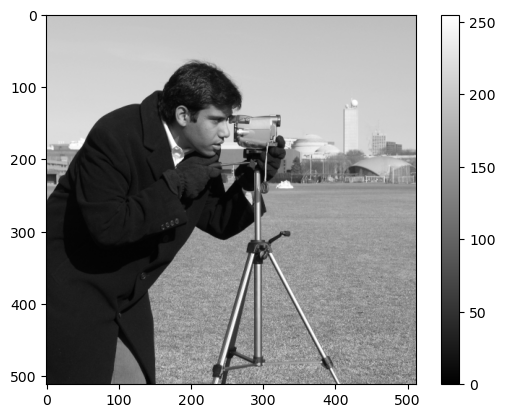

In [18]:
# Load an example image from skimage
image = skimage.data.camera()

# Display the image
plt.imshow(image, cmap='gray')
plt.colorbar(orientation='vertical')
# plt.axhline(y=100, color='r') # draws a red horizontal line at 100
plt.show()

### What do the pixel values mean?

Each number in the array is a **pixel intensity**. For a standard 8-bit grayscale image (`dtype=uint8`), values range from **0** (black) to **255** (white). The pixel at row `r`, column `c` is accessed as `image[r, c]`.

In [19]:
# what is the data type?
type(image)

numpy.ndarray

In [20]:
# what is the shape?
image.shape

(512, 512)

### Intensity profiles

An **intensity profile** is a 1D slice through the image — simply one row (or column) of pixel values plotted as a graph. It lets us quantitatively see how brightness changes across the image, which is useful for choosing thresholds and spotting features like edges.

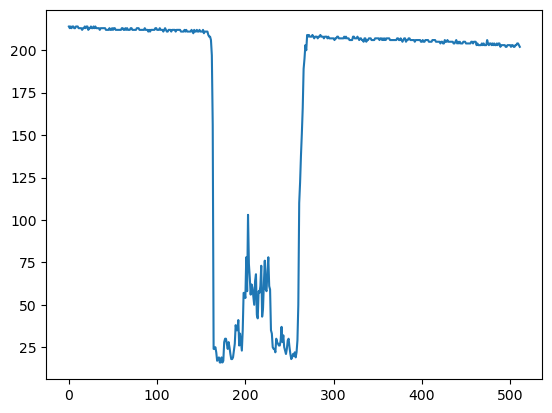

In [21]:
# plotting an intensity profile at y=100
plt.plot(image[100])

### Cropping

Because an image is a 2D array, we can **crop** it with standard numpy slicing: `image[row_start:row_stop, col_start:col_stop]`. This returns a smaller 2D array — no copy is made unless you explicitly ask for one.

(70, 80)


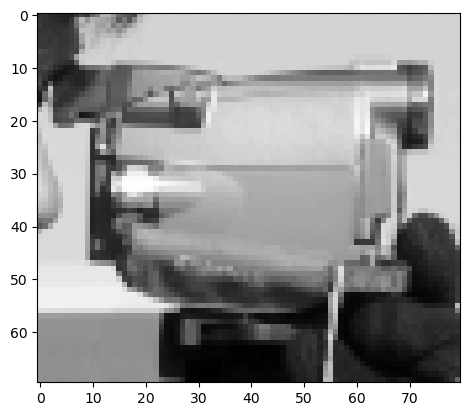

In [22]:
# cropping the region of the camera
plt.imshow(image[130:200, 250:330], cmap='gray')
print(image[130:200, 250:330].shape)

## Exercise 1:
Using Numpy functions, find the average, minimum, and maximum value contained in the image.

# Part 2: Color images are composed of multiple 2D matrices corresponding to Red, Green, and Blue

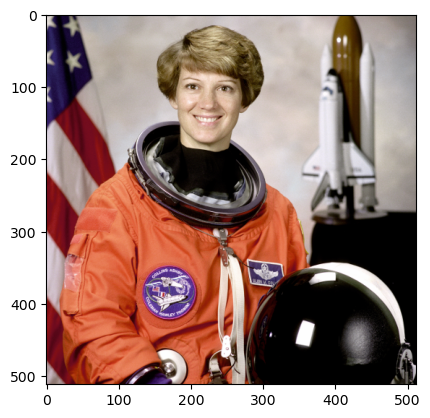

(512, 512, 3)


In [23]:
# Load an example of a colored image
image = skimage.data.astronaut()

# Display the image
plt.imshow(image)
plt.show()

print(image.shape)

Notice that `image.shape` is `(512, 512, 3)` — the third dimension has size 3, one for each color channel (Red, Green, Blue). Each channel is itself a 2D array of intensities (0–255). We access them by their index along the third axis: `image[:, :, 0]` = red, `[:, :, 1]` = green, `[:, :, 2]` = blue.

Text(0.5, 1.0, 'blue')

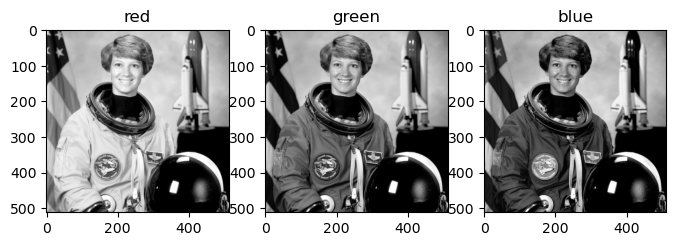

In [24]:
# Split the image into its different channels
red = image[:,:,0]
green = image[:,:,1]
blue = image[:,:,2]

# Display the individual channels
fig, axs = plt.subplots(1,3, figsize=(8,4))
axs[0].imshow(red, cmap='gray')
axs[0].set_title('red')
axs[1].imshow(green, cmap='gray')
axs[1].set_title('green')
axs[2].imshow(blue, cmap='gray')
axs[2].set_title('blue')

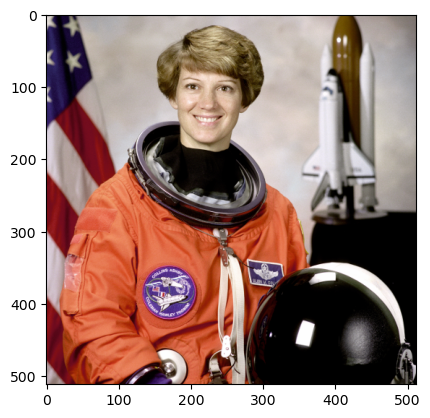

In [25]:
# Combine the three channels into a single numpy array
image_rgb = np.stack((red, green, blue), axis=-1)

# Display the combined image
plt.imshow(image_rgb)
plt.show()

## Exercise 2: Display a new image of the astronaut where the channels are rearranged

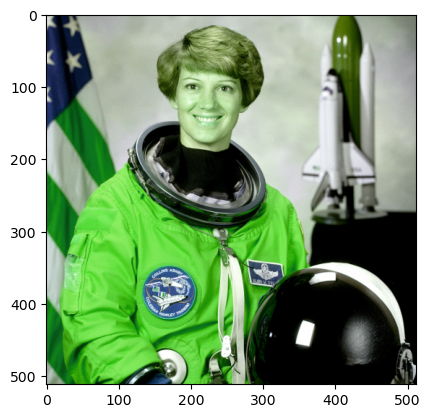

In [26]:
# Combine the three channels into a single numpy array
image_rgb = np.stack((green, red, blue), axis=-1)

# Display the combined image
plt.imshow(image_rgb)
plt.show()

# Part 3: For loops and 3d images

## Using "For loops" to interact with 3D images

First, we download and unzip a cool example 3d image - a MRI scan of a human head.

In [27]:
# Step 1: Specify the URL
url = "https://imagej.net/ij/images/mri-stack.zip"
# Step 2: Download the file
response = requests.get(url)
file_name = "mri-stack.zip"

# Step 3: Save the file locally
with open(file_name, "wb") as file:
    file.write(response.content)

# Step 4: Extract the ZIP file
with zipfile.ZipFile(file_name) as zip_ref:
    zip_ref.extractall("mri-stack")  # Extract to a folder named "mri-stack"

# Verify the extraction
extracted_files = os.listdir("mri-stack")
print("Extracted files:", extracted_files)


Extracted files: ['mri-stack.tif']


In [28]:
image3d = skimage.io.imread('mri-stack/mri-stack.tif')
image3d.shape

(27, 226, 186)

The 3D image has shape `(27, 226, 186)`, meaning:
- **axis 0** (size 27): the slice index — stepping through the head from top to bottom
- **axis 1** (size 226): rows within each slice (height)
- **axis 2** (size 186): columns within each slice (width)

To access slice `i`, we index `image3d[i]`, which gives a 2D array of shape `(226, 186)`.

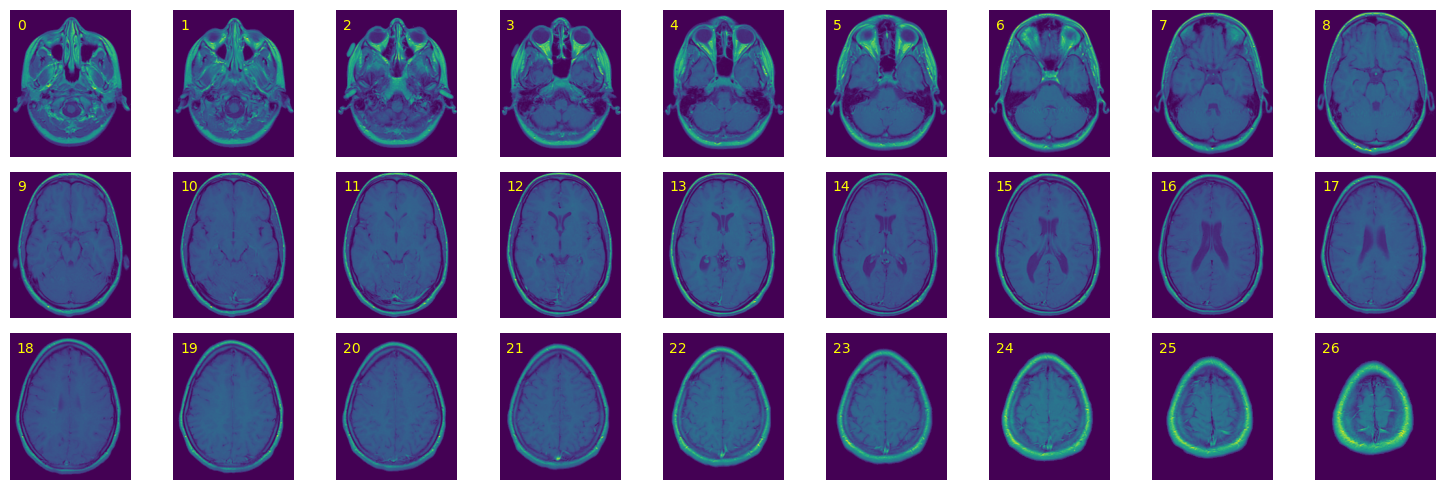

In [29]:
# we know that there are 27 planes in this 3d image
# use a for loop to plot every slice of the 3D image as separate panels

fig, axs = plt.subplots(3, 9, figsize=(15, 5))

N = len(image3d)

for i in range(N):
  axs.ravel()[i].imshow(image3d[i])
  axs.ravel()[i].text(10,30, i, color='yellow')
  axs.ravel()[i].axis('off')
fig.tight_layout()

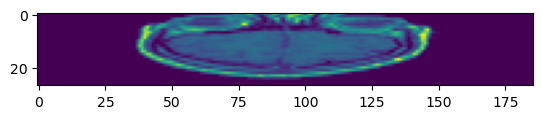

In [30]:
# can you use numpy slicing to create a "side view" of the MRI image??
plt.imshow(image3d[:, 30, :])

# Part 4: Image segmentation and quantitative analysis

We will use data acquired in the Ishihara lab. These are CT26 cells (mouse colon cancer cells) stained for DNA and imaged on a fluorescence microscope.

In [31]:
image = skimage.io.imread('cells_treated.tif')
image.shape

(800, 800)

## Step 1: Pre-processing of image

Pre-processing of images is done to increase the robustness of image analysis. Here we apply a Gaussian filter to lightly smooth the image.

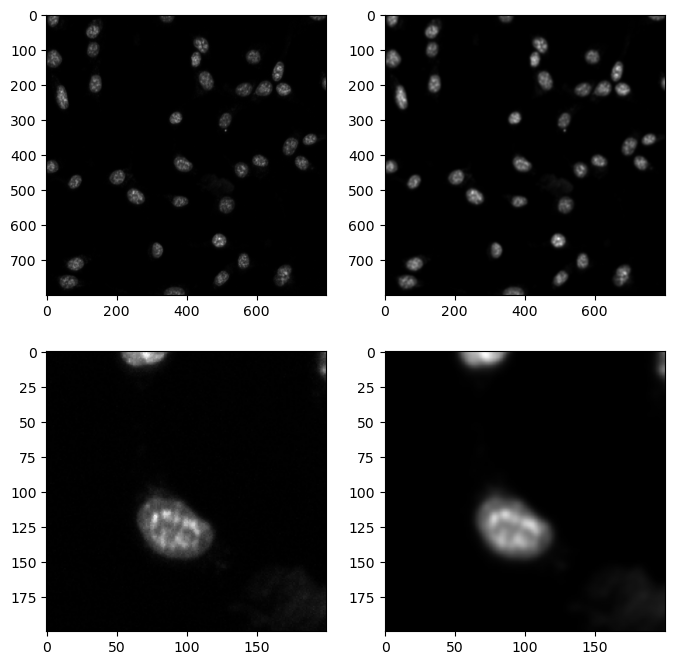

In [32]:
# apply gaussian filter
filtered = skimage.filters.gaussian(image, sigma=2, preserve_range=True)

# display the original and the filtered image
fig, axs = plt.subplots(2,2, figsize=(8,8))
axs[0, 0].imshow(image, cmap='gray')
axs[0, 1].imshow(filtered, cmap='gray')
axs[1, 0].imshow(image[300:500, 300:500], cmap='gray')
axs[1, 1].imshow(filtered[300:500, 300:500], cmap='gray')
plt.show()


Can you see that the image is blurred after filtering? We can see this effect quantitatively by plotting a line profile.

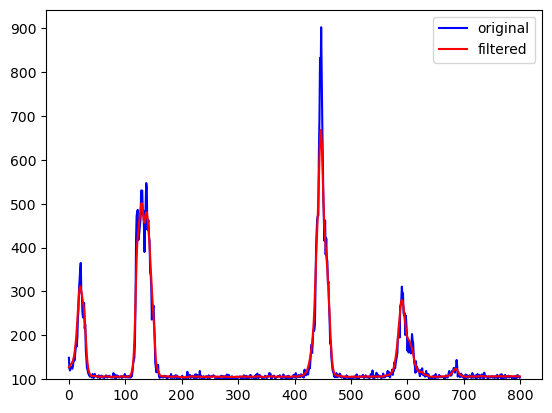

In [33]:
plt.plot(image[100], color='blue', label='original')
plt.plot(filtered[100], color='red', label='filtered')
plt.legend()
plt.ylim(bottom=100);

## Step 2: Image binarization and segementation

We now wish to classify every pixel as:
1. Belonging to a cell
2. or not

the resulting image is a binary array, where all pixels take the value of True or False (boolean).

We can do this by asking if each pixel is above a certain threshold value. Based on the line profile above, a reasonable threshold might be the intensity value of 180.

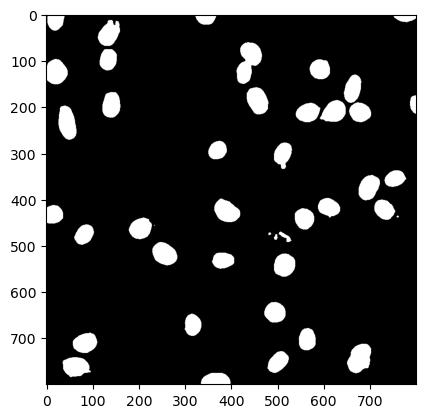

In [34]:
mythreshold = 180
binary = (filtered > mythreshold)
plt.imshow(binary, cmap='gray')

In practice, we want a method to automatically determine the threshold. The Otsu method is a commonly used approach.

291.83527967883816


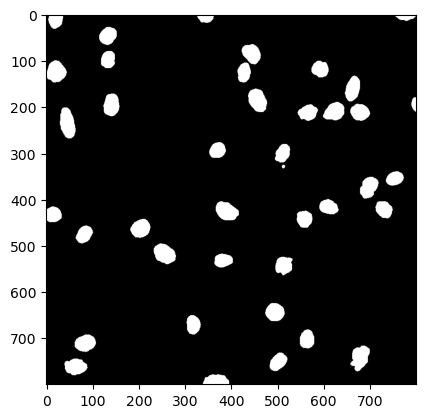

In [35]:
# Binarize the image using Otsu threshold
threshOtsu = skimage.filters.threshold_otsu(filtered)
print(threshOtsu)

binary = filtered > threshOtsu
plt.imshow(binary, cmap='gray')


Now we distinguish the different objects based on the connectivity of the True (white) pixels in the binary image. This is called labeling.

### Labeling connected components

`skimage.measure.label()` assigns a unique integer to each group of connected `True` pixels in the binary image. Background pixels become `0`, the first object becomes `1`, the second `2`, and so on. The result is an integer array the same shape as the input — `labeled.max()` tells us how many objects were found.

40


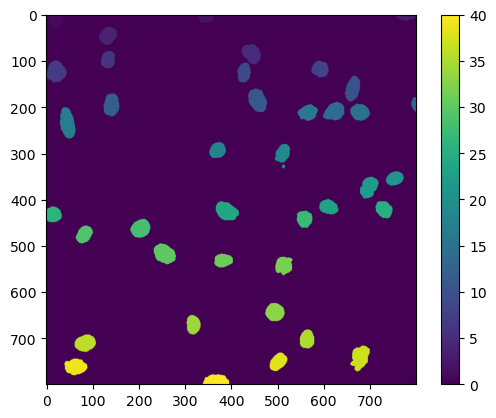

In [36]:
# Label the image using scikit image
labeled = skimage.measure.label(binary)

plt.imshow(labeled)
plt.colorbar(orientation='vertical')

# how many objects are there?
print(labeled.max())

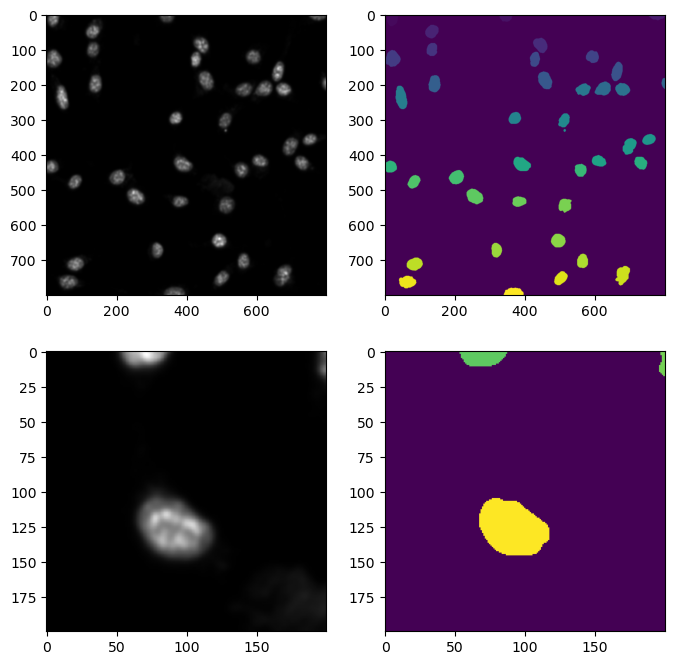

In [37]:
# display the filtered and the labeled image
fig, axs = plt.subplots(2,2, figsize=(8,8))
axs[0, 0].imshow(filtered, cmap='gray')
axs[0, 1].imshow(labeled)
axs[1, 0].imshow(filtered[300:500, 300:500], cmap='gray')
axs[1, 1].imshow(labeled[300:500, 300:500])
plt.show()

## Step 3: Measuring nuclear area

The area of an object is defined as the number of pixels that the object occupies.

In [38]:
# Approach 1: Loop through all the labels and
areas = []
for i in range(1, np.max(labeled)+1):
  area = np.sum(labeled == i)
  areas.append(area)

We can inspect any individual object by selecting just its label. `labeled == 39` creates a boolean array that is `True` only where object #39 is — displaying it shows us the shape of that one cell.

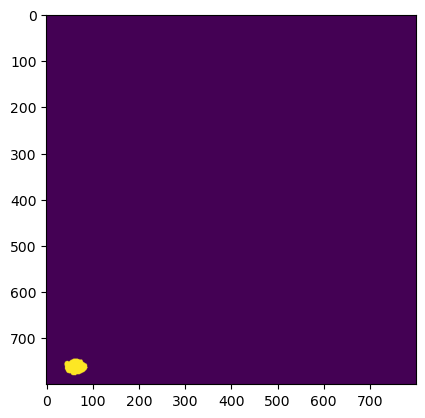

In [39]:
plt.imshow(labeled==39)

In [40]:
# Approach 2: using np.unique, this counts how many
___, areas = np.unique(labeled, return_counts=True)

In [41]:
# Approach 3: Using scikit image to quantify the areas
areas = []
for i in range(np.max(labeled)):
  area = skimage.measure.regionprops(labeled)[i].area
  areas.append(area)


Note the there are many properties that `regionprops` can measure for objects. For example:
- perimeter
- circularity
- center of mass (centroid)

See https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops.


# Bonus: Can you tell if the nuclear area is different in cells_control.tif vs. cells_treated.tif?

## Functions

We just ran the same analysis twice (once for each image). Whenever you find yourself copying and pasting code, it's a sign to write a **function**.

A function packages a block of code under a name so it can be called with different inputs. The syntax is:
```python
def function_name(argument):
    # code here
    return result
```
Below, we wrap the full segmentation pipeline into `measureNuclearArea()` so we can call it on any image file with a single line.

In [42]:
# define the function for repeated use

def measureNuclearArea(filename):

  image = skimage.io.imread(filename)
  filtered = skimage.filters.gaussian(image, sigma=2, preserve_range=True)
  threshOtsu = skimage.filters.threshold_otsu(filtered)
  binary = filtered > threshOtsu
  labeled = skimage.measure.label(binary)

  areas = []
  for i in range(1, np.max(labeled)+1):
    area = np.sum(labeled == i)
    areas.append(area)

  return np.array(areas)

In [43]:
areas_control = measureNuclearArea('cells_control.tif')
areas_treated = measureNuclearArea('cells_treated.tif')

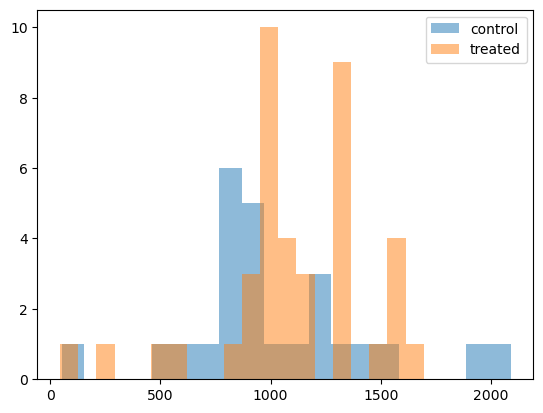

In [44]:
# plot the distributions
plt.hist(areas_control, bins=20, alpha=0.5, label='control')
plt.hist(areas_treated, bins=20, alpha=0.5, label='treated')
plt.legend()

In [45]:
areas_control.mean(), areas_treated.mean()

(np.float64(1022.6), np.float64(1100.45))

### Statistical comparison

Histograms show us the distributions visually, but to decide whether a difference is statistically meaningful we use a **t-test**. The t-test compares the means of two groups and returns a **p-value**: the probability of observing a difference this large (or larger) by chance alone.

A common threshold is `p < 0.05` — if the p-value is below this, the difference is considered statistically significant. Here, `p ≈ 0.42` means there is no significant difference in nuclear area between control and treated cells.

In [46]:
# apply t-test to calculate the p-value
from scipy.stats import ttest_ind

ttest_ind(areas_control, areas_treated)

TtestResult(statistic=np.float64(-0.8061084567080957), pvalue=np.float64(0.42321275615150944), df=np.float64(63.0))

# Part 5: Deep Learning Segmentation with Cellpose

So far, we have segmented cells using a **classical approach**: smooth the image, apply a threshold, and label connected components.

A major challenge with thresholding is that it can fail when cells are touching, unevenly lit, or vary a lot in size. **Cellpose** is a deep learning model trained on thousands of cell images that can segment cells more robustly — without you having to set a threshold.

Rather than looking at pixel intensities, Cellpose predicts a **flow field** (imagine arrows pointing toward the center of each cell), then follows those arrows to find the boundaries of individual cells.

In this section, we will use a phase-contrast timelapse of dividing bacteria.
We will:
1. Load the GIF as a 3D numpy array (frames × height × width)
2. Segment the **first frame** with Cellpose to understand the data
3. Apply the same procedure across **all 60 frames** using a for loop
4. Track how the number of detected bacteria changes over time as they divide

In [47]:
# Install cellpose (run once; safe to re-run)
!pip install cellpose

### Loading a GIF as a 3D array

A GIF is a sequence of image frames — just like the 3D MRI stack from Part 3, but now the first dimension is **time** instead of depth.

We use **Pillow** (`PIL`) to read the GIF frame-by-frame, convert each to grayscale, and stack them into a numpy array of shape `(n_frames, height, width)`. After this, working with a timelapse is exactly the same as working with any 3D numpy array.

In [48]:
from PIL import Image

# Load every frame of the GIF into a 3D numpy array
gif = Image.open('bacteria.gif')

frames = []
try:
    while True:
        frames.append(np.array(gif.convert('L')))  # convert to grayscale
        gif.seek(gif.tell() + 1)
except EOFError:
    pass

frames = np.array(frames)  # shape: (n_frames, height, width)
print(f'Loaded {frames.shape[0]} frames, each {frames.shape[1]}x{frames.shape[2]} pixels')

Loaded 60 frames, each 360x480 pixels


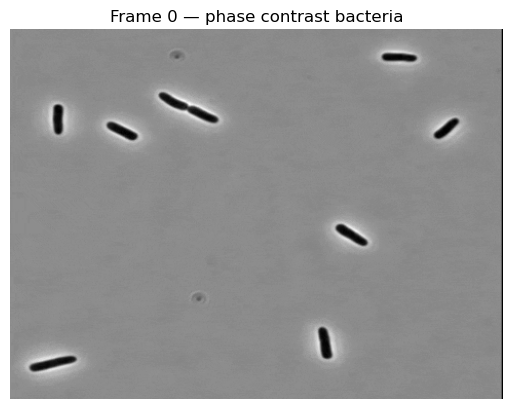

In [49]:
# Display the first frame to inspect the data
plt.imshow(frames[0], cmap='gray')
plt.title('Frame 0 — phase contrast bacteria')
plt.axis('off')
plt.show()

In [53]:
from cellpose import models

# --- Google Colab GPU note ---
# To enable the GPU on Colab: Runtime → Change runtime type → Hardware accelerator → GPU (T4)
# Then set gpu=True below. If no GPU is available, gpu=False still works (a few minutes on CPU).

# Initialize the bacteria/cytoplasm model
# 'cyto3' works well for phase-contrast bacteria (dark objects on light background)
model = models.CellposeModel(gpu=True, pretrained_model='cyto3')

# Segment the first frame
# channels=[0, 0]: grayscale input, no separate nucleus channel
# diameter=None: let Cellpose estimate cell size automatically
# Use separate utility to estimate typical cell diameter from the first frame
from cellpose import utils
diams, _ = utils.diameters(model.eval(frames[0], diameter=None, channels=[0, 0])[0])
print(f'Estimated cell diameter: {diams:.1f} pixels')

# Now segment with the estimated diameter
masks0, flows, styles = model.eval(frames[0], diameter=diams, channels=[0, 0])
print(f'Detected {masks0.max()} bacteria in frame 0')

Estimated cell diameter: 18.9 pixels
Detected 9 bacteria in frame 0


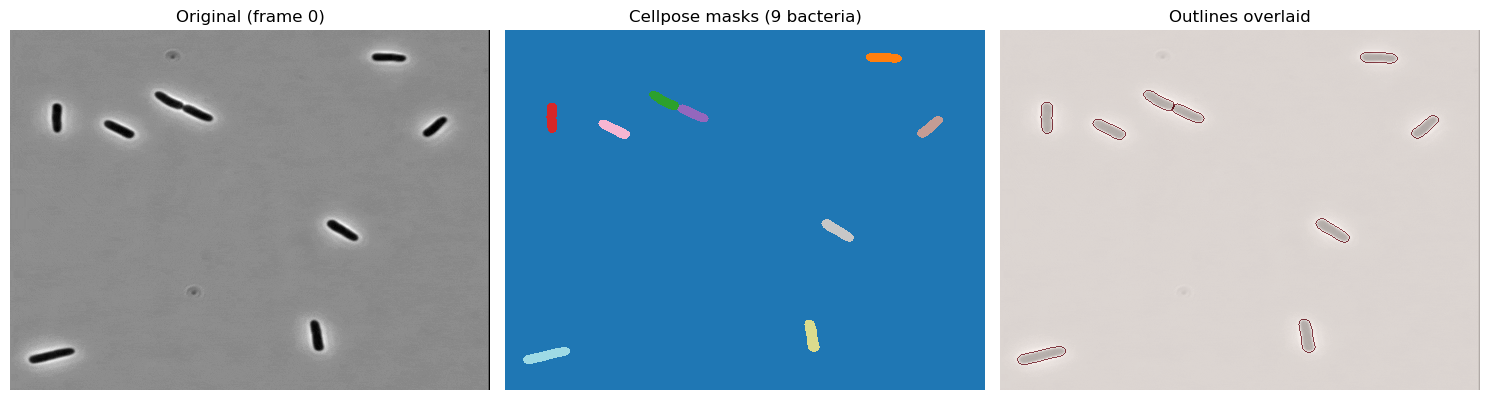

In [51]:
# Visualize segmentation on the first frame
from skimage.segmentation import find_boundaries

outlines0 = find_boundaries(masks0, mode='outer')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(frames[0], cmap='gray')
axes[0].set_title('Original (frame 0)')
axes[0].axis('off')

axes[1].imshow(masks0, cmap='tab20')
axes[1].set_title(f'Cellpose masks ({masks0.max()} bacteria)')
axes[1].axis('off')

axes[2].imshow(frames[0], cmap='gray')
axes[2].imshow(outlines0, cmap='Reds', alpha=0.7)
axes[2].set_title('Outlines overlaid')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Applying segmentation across all frames

Now we combine everything we have learned:
- **For loops** (Part 0 & 3) to iterate over every frame
- **Cellpose** (above) to segment each frame

We fix the cell diameter to the estimate from frame 0 so the model is consistent across frames and we avoid re-estimating it 60 times.

In [52]:
# Apply Cellpose across ALL frames using a for loop
# We reuse the diameter estimate from frame 0 so the model is consistent

n_bacteria = []  # store cell count per frame

for i in range(len(frames)):
    masks_i, _, _ = model.eval(frames[i], diameter=diams, channels=[0, 0])
    n_bacteria.append(masks_i.max())
    if i % 10 == 0:
        print(f'Frame {i:2d}: {masks_i.max()} bacteria')

print(f'\nDone! Processed {len(frames)} frames.')

Frame  0: 9 bacteria


KeyboardInterrupt: 

In [ ]:
# Plot bacteria count over time
plt.figure(figsize=(8, 4))
plt.plot(n_bacteria, marker='o', markersize=4, color='steelblue')
plt.xlabel('Frame')
plt.ylabel('Number of bacteria')
plt.title('Bacterial growth over time (Cellpose)')
plt.tight_layout()
plt.show()

print(f'Frame 0:  {n_bacteria[0]} bacteria')
print(f'Frame {len(n_bacteria)-1}: {n_bacteria[-1]} bacteria')

## Summary

In this notebook we covered:

| Part | Topic | Key tool |
|------|-------|----------|
| 0 | For loops and numpy arrays | `np.array`, `for` loops, indexing |
| 1 | Images as 2D matrices | `skimage.io.imread`, `plt.imshow` |
| 2 | Color images (RGB) | array slicing, `np.stack` |
| 3 | 3D images and for loops | `image3d[i]`, `axs.ravel()` |
| 4 | Classical segmentation | Gaussian filter, Otsu threshold, `label`, `regionprops` |
| 5 | Deep learning segmentation | Cellpose, timelapse analysis |

The central theme: **images are numpy arrays**, and all the array skills from Parts 0–3 apply directly to image analysis.